<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula26b%20-%20ELM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

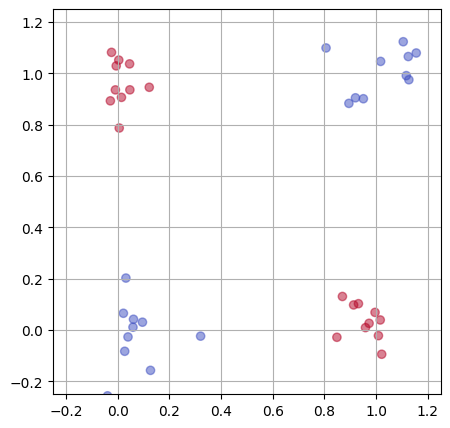

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 40

def generateLogicalDataset(n_samples,
                           func=lambda a, b: bool(a) != bool(b)):
    X, y = make_blobs(n_samples=n_samples,
                      centers=[[0,0],[1,0],[1,1],[0,1]],
                      cluster_std=0.1)
    y = np.array([func(a>0.5, b>0.5) for a, b in zip(X[:,0], X[:,1])], dtype=int) * 2 -1
    return X, y

def plotDataset(X, y, xlim=(-0.25, 1.25), ylim=(-0.25, 1.25)):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', alpha=0.5, cmap="coolwarm")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)

X, y = generateLogicalDataset(n_samples)
plotDataset(X, y)
plt.show()

In [2]:
def defineAxes(X):
  offset = 0.5
  min0, max0 = X[:, 0].min(), X[:, 0].max()
  min1, max1 = X[:, 1].min(), X[:, 1].max()
  return [min0-offset, max0+offset], [min1-offset, max1+offset]

def plotPredictions(model, X):
  axis0, axis1 = defineAxes(X)
  x0s = np.linspace(axis0[0], axis0[1], 100)
  x1s = np.linspace(axis1[0], axis1[1], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap='coolwarm', alpha=0.2)

In [22]:
class PseudoInverse():
  def getW(self, X, y):
    w = np.linalg.pinv(X) @ y
    return w

Accuracy: 1.0


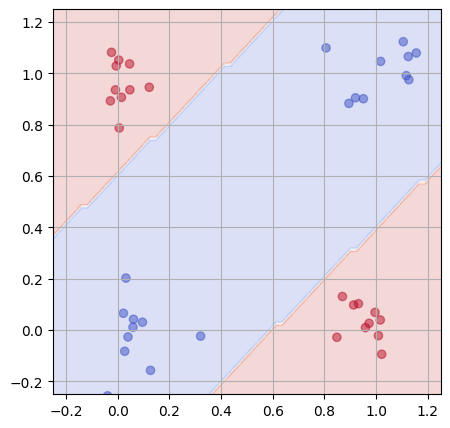

In [23]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class LastLayer(BaseEstimator, ClassifierMixin):
    def __init__(self, trainingAlgorithm=PseudoInverse()):
        self.trainingAlgorithm = trainingAlgorithm

    def fit(self, X, y):
        Xb = include_bias(X)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        self.how = self.trainingAlgorithm.getW(Hb, y.reshape(-1,1))
        return self

    def predict(self, X):
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        y_pred = Hb @ self.how
        return np.sign(y_pred)

model = LastLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


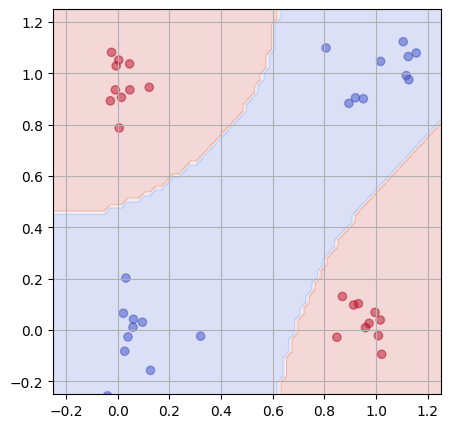

In [45]:
class ELM(BaseEstimator, ClassifierMixin):
    def __init__(self, n_hidden=2, trainingAlgorithm=PseudoInverse()):
        self.n_hidden = n_hidden
        self.trainingAlgorithm = trainingAlgorithm

    def fit(self, X, y):
        Xb = include_bias(X)
        self.ihw = np.random.randn(Xb.shape[1], self.n_hidden)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        self.how = self.trainingAlgorithm.getW(Hb, y.reshape(-1,1))
        return self

    def predict(self, X):
        Xb = include_bias(X)
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        y_pred = Hb @ self.how
        return np.sign(y_pred)

model = ELM(5)
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()